## Step 3: Network Constraints

## STEP 3A — Build the 24-Bus Network in Python

We will:

- Define buses
- Define transmission lines
- Set uniform reactance
- Compute susceptance
- Visualize the network

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy

buses = list(range(1, 25))  # 24 buses


# Uniform reactance assumption
x_uniform = 0.002
b_uniform = 1 / x_uniform  # 500

# Transmission line data (From, To, Capacity)
line_data = [
    (1,2,175), (1,3,175), (1,5,350),
    (2,4,175), (2,6,175),
    (3,9,175), (3,24,400),
    (4,9,175),
    (5,10,350),
    (6,10,175),
    (7,8,350),
    (8,9,175), (8,10,175),
    (9,11,400), (9,12,400),
    (10,11,400), (10,12,400),
    (11,13,500), (11,14,500),
    (12,13,500), (12,23,500),
    (13,23,500),
    (14,16,500),
    (15,16,500), (15,21,1000), (15,24,500),
    (16,17,500), (16,19,500),
    (17,18,500), (17,22,500),
    (18,21,1000),
    (19,20,1000),
    (20,23,1000),
    (21,22,500)
]

G = nx.Graph()

# Add buses
G.add_nodes_from(buses)

# Add lines
for (i, j, cap) in line_data:
    G.add_edge(i, j, capacity=cap, susceptance=b_uniform)


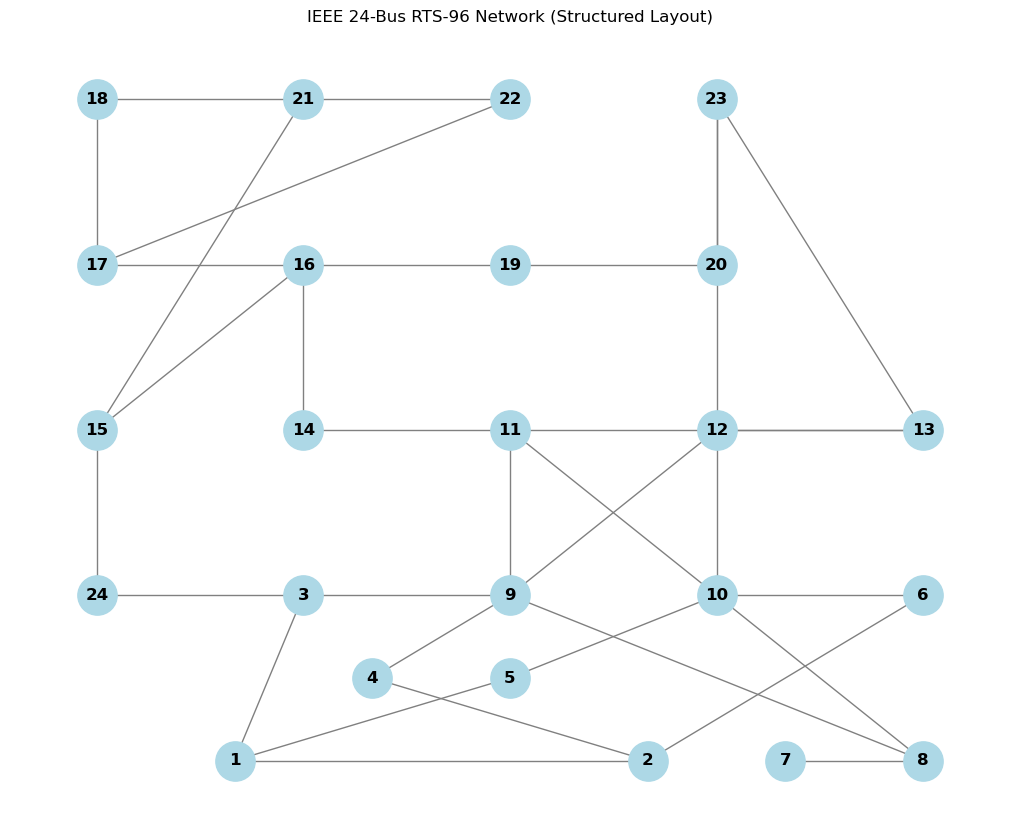

In [6]:
pos = {

    # ----- NORTH -----
    18:(0,4),
    21:(1.5,4),
    22:(3,4),
    23:(4.5,4),

    # ----- UPPER MIDDLE -----
    17:(0,3),
    16:(1.5,3),
    19:(3,3),
    20:(4.5,3),

    # ----- MIDDLE -----
    15:(0,2),
    14:(1.5,2),
    11:(3,2),
    12:(4.5,2),
    13:(6,2),  # slack bus

    # ----- LOWER MIDDLE -----
    24:(0,1),
    3:(1.5,1),
    9:(3,1),
    10:(4.5,1),
    6:(6,1),

    # ----- BOTTOM -----
    1:(1,0),
    4:(2,0.5),
    5:(3,0.5),
    2:(4,0),
    7:(5,0),
    8:(6,0),
}

plt.figure(figsize=(10,8))

nx.draw(G, pos,
        with_labels=True,
        node_size=800,
        node_color='lightblue',
        edge_color='gray',
        font_weight='bold')

plt.title("IEEE 24-Bus RTS-96 Network (Structured Layout)")
plt.axis("off")
plt.show()

## Needed Data from step 1

We keep:
- Generator sets
- Generator capacities
- Generator costs
- Wind availability
- Total demand

In [7]:
# ============================================
# STEP 3 – BASE DATA (FROM STEP 1)
# ============================================

import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import os

# -------------------------
# Sets
# -------------------------

G = range(12)                # Conventional generators
buses = range(1, 25)         # 24 buses

# -------------------------
# Generator Parameters
# -------------------------

P_max = {
    0: 152, 1: 152, 2: 350, 3: 591, 4: 60, 5: 155,
    6: 155, 7: 400, 8: 400, 9: 300, 10: 310, 11: 350
}

C = {
    0: 13.32, 1: 13.32, 2: 20.70, 3: 20.93, 4: 26.11,
    5: 10.52, 6: 10.52, 7: 6.02, 8: 5.47, 9: 0.00,
    10: 10.52, 11: 10.89
}

# -------------------------
# Demand
# -------------------------

D_t = 2650.5      # Total system demand

# -------------------------
# Wind (already computed)
# -------------------------

P_w_bar = 173.73   # Replace with your computed value

## 3B.1 Generator-to-Bus Mapping

## 3B.2 Generator and Demand Distribution

We now convert total demand → nodal demand.

In [8]:
# ============================================
# STEP 3 – Generator & Wind Location
# ============================================

# Generator-to-bus mapping (RTS-96 consistent)

gen_bus = {
    0: 1,
    1: 2,
    2: 7,
    3: 13,
    4: 15,
    5: 15,
    6: 16,
    7: 18,
    8: 21,
    9: 22,
    10: 23,
    11: 23
}

# Wind location
wind_bus = 8  # Bus 8 has the wind generator

In [9]:
# ============================================
# STEP 3 – Exact Load Distribution
# ============================================

load_percent = {
    1:3.8, 2:3.4, 3:6.3, 4:2.6, 5:2.5,
    6:4.8, 7:4.4, 8:6.0, 9:6.1, 10:6.8,
    13:9.3, 14:6.8, 15:11.1, 16:3.5,
    18:11.7, 19:6.4, 20:4.5
}

# Convert to fractions
load_share = {n: load_percent[n]/100 for n in load_percent}

# Check total ≈ 1
print("Sum of load shares:", sum(load_share.values()))

# Build nodal demand
D_bus = {
    n: D_t * load_share.get(n, 0)
    for n in buses
}

Sum of load shares: 1.0


## Build the model!!!!

In [10]:
# ============================================
# STEP 3B – NODAL DC MARKET CLEARING
# ============================================

model = gp.Model("Nodal_DC_OPF")

# -------------------------
# Variables
# -------------------------

# Generation
p_i = model.addVars(G, lb=0,
                    ub=[P_max[i] for i in G],
                    name="p_i")

# Wind
p_w = model.addVar(lb=0, ub=P_w_bar, name="p_w")

# Voltage angles
theta = model.addVars(buses, lb=-GRB.INFINITY, name="theta")

# Line flows
f = {}
for (i, j, cap) in line_data:
    f[i, j] = model.addVar(lb=-cap, ub=cap, name=f"f_{i}_{j}")

Set parameter Username
Set parameter LicenseID to value 2623061

--------------------------------------------
--------------------------------------------

Academic license - for non-commercial use only - expires 2026-02-17


DC Flow Constraints

In [11]:
b = 500  # uniform susceptance

for (i, j, cap) in line_data:
    model.addConstr(
        f[i, j] == b * (theta[i] - theta[j]),
        name=f"dcflow_{i}_{j}"
    )

Nodal Power Balance

In [12]:
balance = {}

for n in buses:

    # Generation at bus n
    gen_sum = gp.quicksum(
        p_i[i] for i in G if gen_bus[i] == n
    )

    # Wind at bus n
    wind_term = p_w if n == wind_bus else 0

    # Demand at bus n
    demand = D_bus[n]

    # Flows leaving bus n
    flow_out = gp.quicksum(
        f[n, j] for (i, j, cap) in line_data if i == n
    )

    # Flows entering bus n
    flow_in = gp.quicksum(
        f[i, n] for (i, j, cap) in line_data if j == n
    )

    balance[n] = model.addConstr(
        gen_sum + wind_term - demand
        == flow_out - flow_in,
        name=f"balance_{n}"
    )

Slack Bus here

In [13]:
model.addConstr(theta[13] == 0, name="slack_bus")

<gurobi.Constr *Awaiting Model Update*>

Optimize by only accounting for costs as demand and Utility are steady

In [14]:
model.setObjective(
    gp.quicksum(C[i] * p_i[i] for i in G),
    GRB.MINIMIZE
)

model.optimize()

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: AMD Ryzen 5 4600H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 59 rows, 71 columns and 184 nonzeros
Model fingerprint: 0xe2f3ba72
Coefficient statistics:
  Matrix range     [1e+00, 5e+02]
  Objective range  [5e+00, 3e+01]
  Bounds range     [6e+01, 1e+03]
  RHS range        [7e+01, 3e+02]
Presolve removed 33 rows and 33 columns
Presolve time: 0.03s
Presolved: 26 rows, 38 columns, 120 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   1.713944e+03   0.000000e+00      0s
      15    2.1106519e+04   0.000000e+00   0.000000e+00      0s

Solved in 15 iterations and 0.05 seconds (0.00 work units)
Optimal objective  2.110651900e+04


## Extract the results

Extract Nodal prices and conjested lines

In [15]:
lambda_n = {}

print("\n========== NODAL PRICES ==========\n")

for n in buses:
    lambda_n[n] = balance[n].Pi
    print(f"Bus {n}: λ = {lambda_n[n]:.2f} €/MWh")



print("\n========== CONGESTED LINES ==========\n")

for (i, j, cap) in line_data:
    if abs(f[i, j].X) > 0.999 * cap:
        print(f"Line {i}-{j} congested")


========== NODAL PRICES ==========

Bus 1: λ = 20.70 €/MWh
Bus 2: λ = 20.70 €/MWh
Bus 3: λ = 20.70 €/MWh
Bus 4: λ = 20.70 €/MWh
Bus 5: λ = 20.70 €/MWh
Bus 6: λ = 20.70 €/MWh
Bus 7: λ = 20.70 €/MWh
Bus 8: λ = 20.70 €/MWh
Bus 9: λ = 20.70 €/MWh
Bus 10: λ = 20.70 €/MWh
Bus 11: λ = 20.70 €/MWh
Bus 12: λ = 20.70 €/MWh
Bus 13: λ = 20.70 €/MWh
Bus 14: λ = 20.70 €/MWh
Bus 15: λ = 20.70 €/MWh
Bus 16: λ = 20.70 €/MWh
Bus 17: λ = 20.70 €/MWh
Bus 18: λ = 20.70 €/MWh
Bus 19: λ = 20.70 €/MWh
Bus 20: λ = 20.70 €/MWh
Bus 21: λ = 20.70 €/MWh
Bus 22: λ = 20.70 €/MWh
Bus 23: λ = 20.70 €/MWh
Bus 24: λ = 20.70 €/MWh

========== CONGESTED LINES ==========



In [16]:
# ============================================
# STEP 3B – RESULTS & INTERPRETATION
# ============================================

if model.status == GRB.OPTIMAL:

    print("\n========== NODAL RESULTS ==========\n")

    # -------------------------
    # Total generation cost
    # -------------------------
    total_cost = sum(C[i] * p_i[i].X for i in G)
    print(f"Total generation cost: {total_cost:.2f} €")

    # -------------------------
    # Social welfare
    # -------------------------
    total_utility = sum(D_bus[n] * 100 for n in buses)  # U_d = 100
    social_welfare = total_utility - total_cost
    print(f"Social welfare: {social_welfare:.2f} €")

    # -------------------------
    # Nodal prices
    # -------------------------
    print("\nNodal Prices (€/MWh):")
    lambda_n = {}

    for n in buses:
        lambda_n[n] = balance[n].Pi
        print(f"Bus {n}: {lambda_n[n]:.2f}")

    # -------------------------
    # Check congestion
    # -------------------------
    print("\nCongested Lines:")
    congested = False

    for (i, j, cap) in line_data:
        if abs(f[i, j].X) > 0.999 * cap:
            print(f"Line {i}-{j} at capacity")
            congested = True

    if not congested:
        print("No lines congested.")


========== NODAL RESULTS ==========

Total generation cost: 21106.52 €
Social welfare: 243943.48 €

Nodal Prices (€/MWh):
Bus 1: 20.70
Bus 2: 20.70
Bus 3: 20.70
Bus 4: 20.70
Bus 5: 20.70
Bus 6: 20.70
Bus 7: 20.70
Bus 8: 20.70
Bus 9: 20.70
Bus 10: 20.70
Bus 11: 20.70
Bus 12: 20.70
Bus 13: 20.70
Bus 14: 20.70
Bus 15: 20.70
Bus 16: 20.70
Bus 17: 20.70
Bus 18: 20.70
Bus 19: 20.70
Bus 20: 20.70
Bus 21: 20.70
Bus 22: 20.70
Bus 23: 20.70
Bus 24: 20.70

Congested Lines:
No lines congested.


## Do congestion Rent

In [17]:
# --------------------------------------------
# Congestion Rent
# --------------------------------------------

congestion_rent = 0

for (i, j, cap) in line_data:
    congestion_rent += (lambda_n[i] - lambda_n[j]) * f[i, j].X

print(f"\nCongestion rent: {congestion_rent:.2f} €")


Congestion rent: -0.00 €


## Visualization

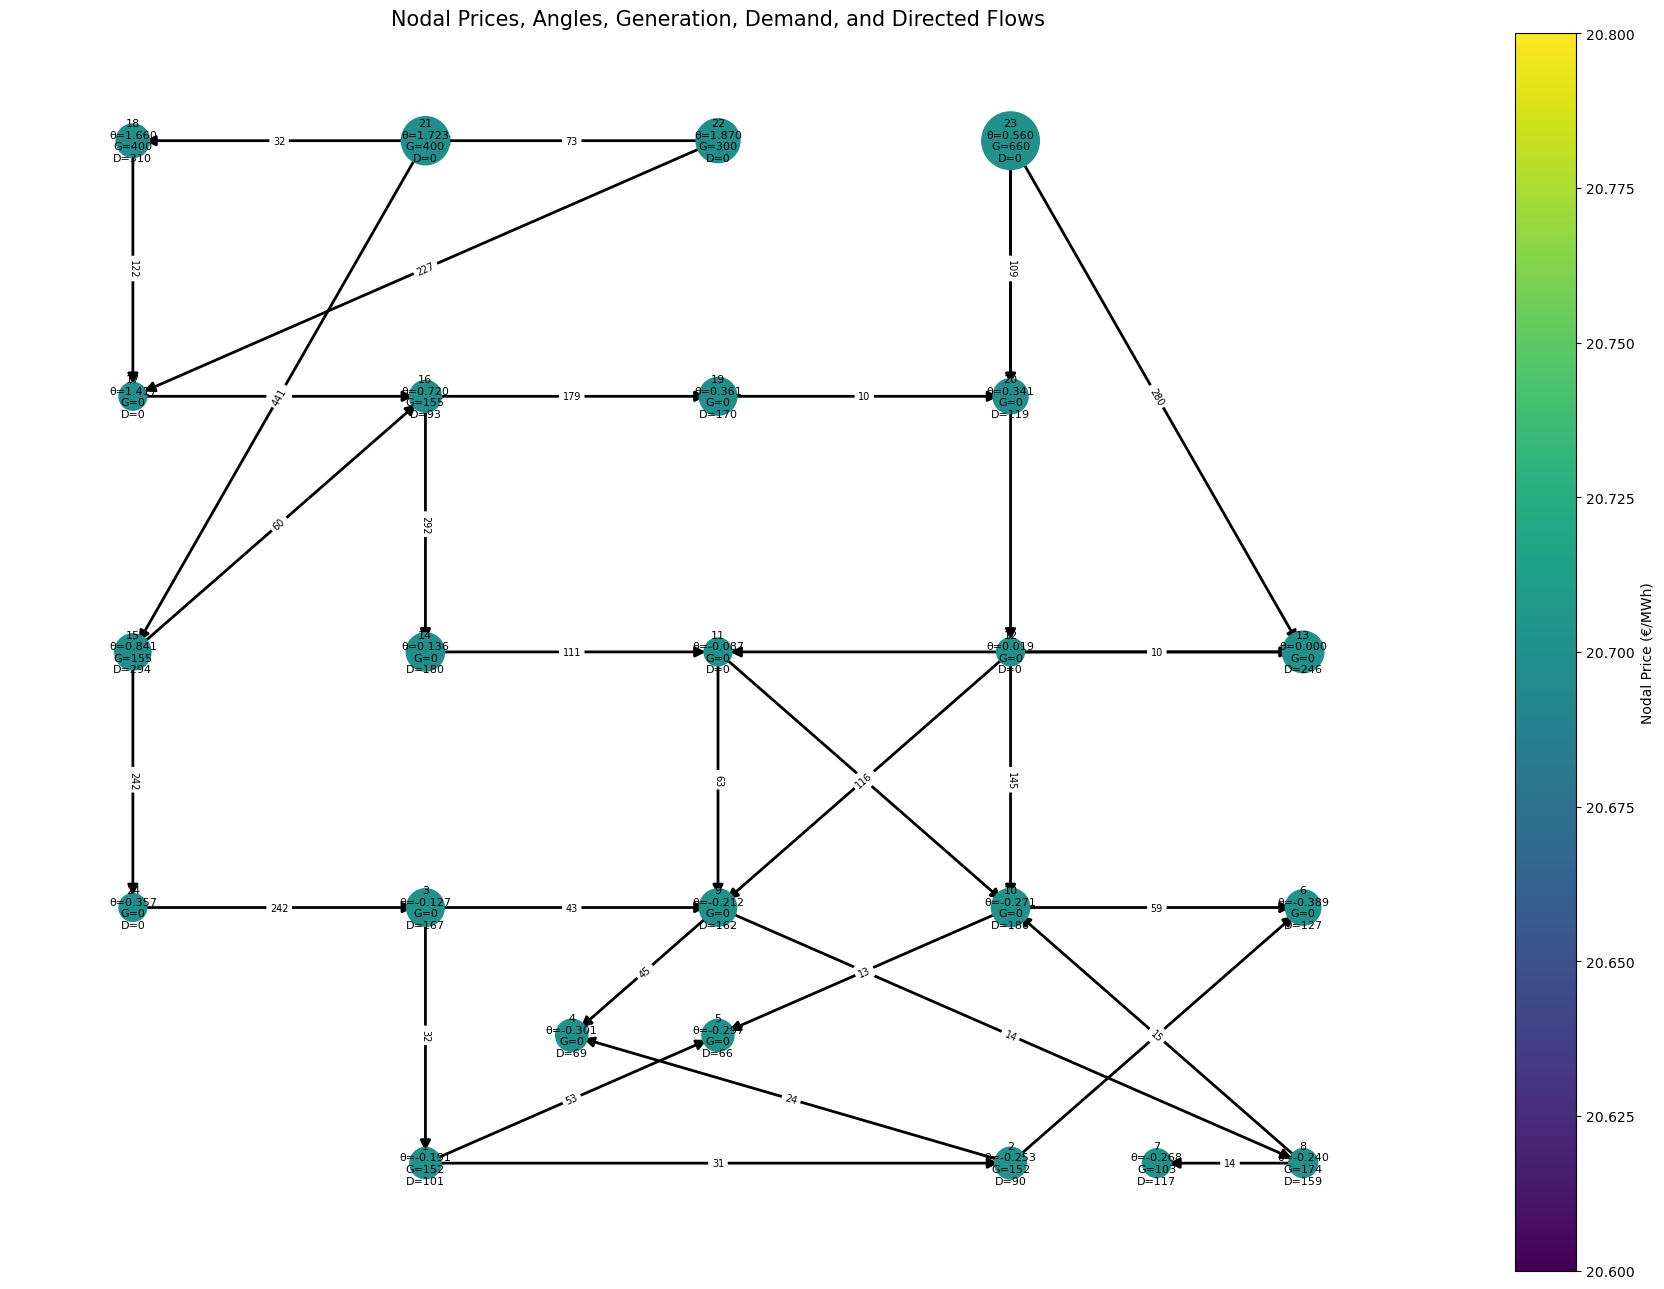

In [21]:
# ============================================
# FULL PROFESSIONAL NETWORK VISUALIZATION
# (Price, Theta, Generation, Demand, Flows)
# ============================================

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# Build directed graph for arrows
# -------------------------
G_vis = nx.DiGraph()
G_vis.add_nodes_from(range(1, 25))

for (i, j, cap) in line_data:
    flow = f[i, j].X
    if flow >= 0:
        G_vis.add_edge(i, j, flow=flow, capacity=cap)
    else:
        G_vis.add_edge(j, i, flow=abs(flow), capacity=cap)

# -------------------------
# Structured Layout (stretched)
# -------------------------
pos = {
    18:(0,4), 21:(2,4), 22:(4,4), 23:(6,4),
    17:(0,3), 16:(2,3), 19:(4,3), 20:(6,3),
    15:(0,2), 14:(2,2), 11:(4,2), 12:(6,2), 13:(8,2),
    24:(0,1), 3:(2,1), 9:(4,1), 10:(6,1), 6:(8,1),
    1:(2,0), 4:(3,0.5), 5:(4,0.5), 2:(6,0), 7:(7,0), 8:(8,0),
}

# -------------------------
# Prices (fix scale if equal)
# -------------------------
prices = np.array([lambda_n[n] for n in G_vis.nodes()])
p_min = prices.min()
p_max = prices.max()

if abs(p_max - p_min) < 1e-6:
    p_min -= 0.1
    p_max += 0.1

# -------------------------
# Node sizes (injection magnitude)
# -------------------------
node_sizes = []
for n in G_vis.nodes():
    gen = sum(p_i[i].X for i in G if gen_bus[i] == n)
    wind = p_w.X if n == wind_bus else 0
    demand = D_bus[n]
    net = abs(gen + wind - demand)
    node_sizes.append(400 + 2*net)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(18,13))

# Nodes
nodes = nx.draw_networkx_nodes(
    G_vis,
    pos,
    node_color=prices,
    cmap="viridis",
    vmin=p_min,
    vmax=p_max,
    node_size=node_sizes
)

# Edges with arrows
nx.draw_networkx_edges(
    G_vis,
    pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=15,
    width=2
)

# -------------------------
# Node Labels (Bus, Theta, Generation, Demand)
# -------------------------
labels = {}

for n in G_vis.nodes():

    gen = sum(p_i[i].X for i in G if gen_bus[i] == n)
    wind = p_w.X if n == wind_bus else 0
    total_gen = gen + wind
    demand = D_bus[n]

    labels[n] = (
        f"{n}\n"
        f"θ={theta[n].X:.3f}\n"
        f"G={total_gen:.0f}\n"
        f"D={demand:.0f}"
    )

nx.draw_networkx_labels(G_vis, pos, labels=labels, font_size=8)

# -------------------------
# Flow Labels
# -------------------------
edge_labels = {
    (u,v): f"{data['flow']:.0f}"
    for u,v,data in G_vis.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G_vis,
    pos,
    edge_labels=edge_labels,
    font_size=7
)

# Colorbar
cbar = plt.colorbar(nodes)
cbar.set_label("Nodal Price (€/MWh)")

plt.title("Nodal Prices, Angles, Generation, Demand, and Directed Flows", fontsize=15)
plt.axis("off")
plt.tight_layout()
plt.show()